# Práctica 4 — Medidas de Heterogeneidad
## IQV, Gini-Simpson y entropía de Shannon sobre variables cualitativas
**Jesús** · ENDIREH 2021

Tema sensible: los datos representan experiencias reales. Las categorías
no deben leerse como juicios sobre personas o grupos.

In [1]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from config.rutas import RUTA_PARQUET_LIMPIO, RUTA_FIGURAS, RUTA_TABLAS
from src.heterogeneidad import (
    gini_simpson, iqv, entropia_shannon, entropia_maxima, tabla_heterogeneidad,
)

sns.set_theme(style="whitegrid")
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_TABLAS.mkdir(parents=True, exist_ok=True)

In [2]:
df = pl.read_parquet(RUTA_PARQUET_LIMPIO)
print(df.shape)
df.head(3)

(105296, 26)


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta,edad_primer_union_imputada,num_hijos_imputado
i64,cat,i64,str,i64,i64,cat,i64,cat,i64,i64,str,f64,i64,str,i64,str,i64,str,i64,str,i8,f64,i64,bool,bool
22,"""queretaro""",11,"""EL MARQUÃS""",21,3,"""c1""",6,"""soltera""",3,2,"""No""",null,2,"""No""",2,"""No""",2,"""No""",1,"""Sí""",0,427.0,2021,true,true
22,"""queretaro""",12,"""PEDRO ESCOBEDO""",21,3,"""a1""",5,"""casada""",2,2,"""No""",null,2,"""No""",2,"""No""",2,"""No""",1,"""Sí""",0,294.0,2021,true,false
13,"""hidalgo""",70,"""TLAHUELILPAN""",21,2,"""b1""",2,"""separada""",2,1,"""Sí""",1000.0,1,"""Sí""",2,"""No""",2,"""No""",2,"""No""",1,263.0,2021,true,false


## 1. Variables categóricas a analizar

Se eligen las cualitativas del dataset: nom_entidad, nivel_escolaridad,
estado_civil_desc, estrato_socioeconomico, sufrio_violencia_pareja.
No se ponderan por factor_expansion: los índices de heterogeneidad operan
sobre proporciones de categorías, no sobre poblaciones.

In [3]:
VARS = [
    "nom_entidad",
    "nivel_escolaridad",
    "estado_civil_desc",
    "estrato_socioeconomico",
    "sufrio_violencia_pareja",
]

tabla = tabla_heterogeneidad(df, VARS)
tabla

variable,k,gini_simpson,iqv,shannon,shannon_max,shannon_rel
str,i64,f64,f64,f64,f64,f64
"""nom_entidad""",32,0.968703,0.999951,4.998904,5.0,0.999781
"""nivel_escolaridad""",6,0.613324,0.735988,1.849858,2.584963,0.715623
"""estado_civil_desc""",6,0.745609,0.894731,2.218037,2.584963,0.858054
"""estrato_socioeconomico""",4,0.642859,0.857145,1.71467,2.0,0.857335
"""sufrio_violencia_pareja""",2,0.297064,0.594129,0.68326,1.0,0.68326


## 2. Resultados

In [4]:
conteos_esc = (
    df.group_by("nivel_escolaridad")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
conteos_esc

nivel_escolaridad,n
cat,u32
"""a1""",61669
"""c1""",14425
"""b1""",12546
"""b2""",9497
"""c2""",4765
"""a2""",2394


In [5]:
gs = gini_simpson(conteos_esc["n"])
q  = iqv(conteos_esc["n"])
h  = entropia_shannon(conteos_esc["n"])
hmax = entropia_maxima(conteos_esc.height)

print(f"Gini-Simpson : {gs:.4f}")
print(f"IQV          : {q:.4f}")
print(f"Shannon      : {h:.4f} bits (max {hmax:.4f})")
print(f"Shannon rel  : {h / hmax:.4f}")

Gini-Simpson : 0.6133
IQV          : 0.7360
Shannon      : 1.8499 bits (max 2.5850)
Shannon rel  : 0.7156


## 3. Figura comparativa

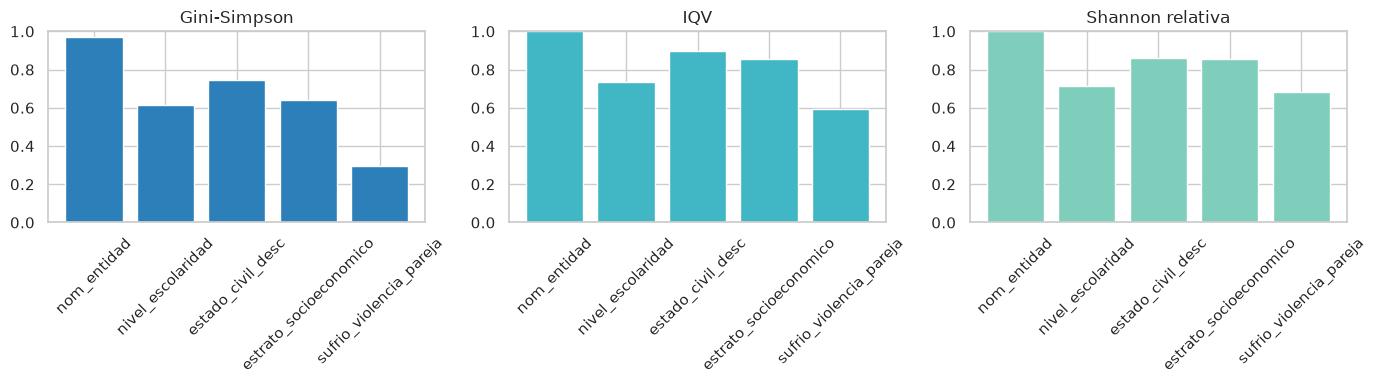

In [6]:
t = tabla.to_pandas().set_index("variable")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(t.index, t["gini_simpson"], color="#2c7fb8")
axes[0].set_title("Gini-Simpson")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(t.index, t["iqv"], color="#41b6c4")
axes[1].set_title("IQV")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(t.index, t["shannon_rel"], color="#7fcdbb")
axes[2].set_title("Shannon relativa")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "03_barras_heterogeneidad.png", dpi=150)
plt.show()

### Interpretación

Los tres índices ordenan las variables de forma parecida pero no idéntica.
La entropía relativa es la más comparable entre variables con distinto
número de categorías.

- nom_entidad: 32 categorías, entropía relativa cercana a ___.
- nivel_escolaridad: 6 categorías, Shannon = ___ bits de ___ posibles.
- sufrio_violencia_pareja: binaria, heterogeneidad ___ por el desbalance
  hacia el grupo sin violencia.

El Gini-Simpson se lee como la probabilidad de que dos mujeres elegidas al
azar estén en categorías distintas. El IQV normaliza ese valor para que el
máximo sea siempre 1. La entropía de Shannon es la más informativa para
comparaciones y modelos posteriores.

In [7]:
import json
res = {
    "nivel_escolaridad": {
        "k": conteos_esc.height,
        "gini_simpson": float(gs),
        "iqv": float(q),
        "shannon_bits": float(h),
        "shannon_max": float(hmax),
        "shannon_rel": float(h / hmax),
    }
}
tabla_full = tabla.to_dicts()
res["tabla_completa"] = tabla_full

with open(RUTA_TABLAS / "resultados_heterogeneidad.json", "w") as f:
    json.dump(res, f, indent=2, ensure_ascii=False)
res

{'nivel_escolaridad': {'k': 6,
  'gini_simpson': 0.6133235298350173,
  'iqv': 0.7359882358020207,
  'shannon_bits': 1.849858017576307,
  'shannon_max': 2.584962500721156,
  'shannon_rel': 0.7156227670847184},
 'tabla_completa': [{'variable': 'nom_entidad',
   'k': 32,
   'gini_simpson': 0.968702767538154,
   'iqv': 0.9999512439103525,
   'shannon': 4.998903950140657,
   'shannon_max': 5.0,
   'shannon_rel': 0.9997807900281315},
  {'variable': 'nivel_escolaridad',
   'k': 6,
   'gini_simpson': 0.6133235298350173,
   'iqv': 0.7359882358020207,
   'shannon': 1.8498580175763069,
   'shannon_max': 2.584962500721156,
   'shannon_rel': 0.7156227670847183},
  {'variable': 'estado_civil_desc',
   'k': 6,
   'gini_simpson': 0.7456089332820759,
   'iqv': 0.8947307199384911,
   'shannon': 2.2180367688219214,
   'shannon_max': 2.584962500721156,
   'shannon_rel': 0.8580537505681922},
  {'variable': 'estrato_socioeconomico',
   'k': 4,
   'gini_simpson': 0.6428588184243544,
   'iqv': 0.8571450912324

### Pregunta 3 — Orientación para modelado posterior

Las medidas de heterogeneidad orientan las siguientes decisiones:

1. Variables con entropía muy baja (sufrio_violencia_pareja) aportan poca
   información al modelo; conviene tratarlas con técnicas específicas de
   desbalance (SMOTE, class_weight) en lugar de codificarlas tal cual.
2. Variables con entropía alta y muchas categorías (nom_entidad) son
   candidatas a reducción dimensional o a target encoding.
3. nivel_escolaridad tiene heterogeneidad moderada: las categorías a2 y c2
   son minoritarias y podrían agruparse en "otras" antes de un modelo.
4. Para clustering territorial, combinar la heterogeneidad categórica con
   la prevalencia ponderada por entidad evita clusters espurios.
5. El IQV y la Shannon relativa permiten comparar qué variables categóricas
   son más útiles antes de aplicar K-modes o clustering jerárquico.